In [ ]:
# Cell 1: Imports
import numpy as np
import time
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

PyTorch version: 2.10.0+cu128
GPU available: True


In [ ]:
# Cell 2: Load CIFAR-10 Dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Download dataset
train_full = datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform)
test_full  = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Use small subset to keep evaluation fast
train_subset = Subset(train_full, range(5000))
val_subset   = Subset(test_full,  range(1000))

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_subset,   batch_size=64, shuffle=False)

print("Dataset loaded successfully!")
print(f"Training samples : {len(train_subset)}")
print(f"Validation samples: {len(val_subset)}")

100%|██████████| 170M/170M [00:03<00:00, 43.8MB/s]


Dataset loaded successfully!
Training samples : 5000
Validation samples: 1000


In [ ]:
# Cell 3: Search Space Definition
OPS        = ['conv3x3', 'conv5x5', 'maxpool', 'skip']
NUM_LAYERS = 5
PARAM_BUDGET = 500_000

print(f"Operations available : {OPS}")
print(f"Number of layers     : {NUM_LAYERS}")
print(f"Total search space   : {len(OPS)**NUM_LAYERS} architectures")
print(f"Parameter budget     : {PARAM_BUDGET:,}")

Operations available : ['conv3x3', 'conv5x5', 'maxpool', 'skip']
Number of layers     : 5
Total search space   : 1024 architectures
Parameter budget     : 500,000


In [ ]:
# Cell 4: Build CNN from Architecture Config
def build_model(arch_config):
    layers = []
    in_channels = 3  # CIFAR-10 is RGB

    for op in arch_config:
        if op == 'conv3x3':
            layers += [
                nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.BatchNorm2d(32)
            ]
            in_channels = 32

        elif op == 'conv5x5':
            layers += [
                nn.Conv2d(in_channels, 32, kernel_size=5, padding=2),
                nn.ReLU(),
                nn.BatchNorm2d(32)
            ]
            in_channels = 32

        elif op == 'maxpool':
            layers.append(nn.MaxPool2d(kernel_size=2, stride=2))

        elif op == 'skip':
            layers.append(nn.Identity())

    # Final pooling to collapse spatial dimensions
    layers.append(nn.AdaptiveAvgPool2d((1, 1)))

    # Store in_channels for classifier
    final_channels = in_channels

    class NASModel(nn.Module):
        def __init__(self):
            super().__init__()
            self.features   = nn.Sequential(*layers)
            self.classifier = nn.Linear(final_channels, 10)

        def forward(self, x):
            x = self.features(x)
            x = x.view(x.size(0), -1)
            return self.classifier(x)

    return NASModel()

print("Model builder defined!")

Model builder defined!


In [ ]:
# Cell 5: Evaluation Function
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

def evaluate_architecture(arch_config, epochs=3):
    try:
        model = build_model(arch_config).to(device)
    except Exception as e:
        return 0.0

    # Check parameter budget
    total_params = sum(p.numel() for p in model.parameters())
    if total_params > PARAM_BUDGET:
        return 0.0

    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    # Train
    model.train()
    for epoch in range(epochs):
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()

    # Validate
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            preds = model(images).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)

    return correct / total

print("Evaluation function defined!")

Using device: cuda
Evaluation function defined!


In [ ]:
# Cell 6: Greedy Search
def greedy_search():
    print("=" * 40)
    print("GREEDY SEARCH STARTED")
    print("=" * 40)

    best_arch = []
    start_time = time.time()
    architectures_evaluated = 0

    for layer_idx in range(NUM_LAYERS):
        best_op  = None
        best_acc = -1

        for op in OPS:
            # Fix layers decided so far + try current op + fill rest with conv3x3
            candidate = best_arch + [op] + ['conv3x3'] * (NUM_LAYERS - layer_idx - 1)
            acc = evaluate_architecture(candidate)
            architectures_evaluated += 1

            print(f"  Layer {layer_idx+1} | Op: {op:<10} | Acc: {acc:.4f}")

            if acc > best_acc:
                best_acc = acc
                best_op  = op

        best_arch.append(best_op)
        print(f"  >> Layer {layer_idx+1} BEST: {best_op} (acc={best_acc:.4f})\n")

    elapsed = time.time() - start_time

    print("=" * 40)
    print(f"Greedy Best Architecture : {best_arch}")
    print(f"Greedy Best Accuracy     : {best_acc:.4f}")
    print(f"Time Taken               : {elapsed:.2f}s")
    print(f"Architectures Evaluated  : {architectures_evaluated}")
    print("=" * 40)

    return best_arch, best_acc, elapsed, architectures_evaluated

# Run it
g_arch, g_acc, g_time, g_evals = greedy_search()

GREEDY SEARCH STARTED
  Layer 1 | Op: conv3x3    | Acc: 0.4120
  Layer 1 | Op: conv5x5    | Acc: 0.4120
  Layer 1 | Op: maxpool    | Acc: 0.3890
  Layer 1 | Op: skip       | Acc: 0.3810
  >> Layer 1 BEST: conv3x3 (acc=0.4120)

  Layer 2 | Op: conv3x3    | Acc: 0.3890
  Layer 2 | Op: conv5x5    | Acc: 0.4020
  Layer 2 | Op: maxpool    | Acc: 0.4460
  Layer 2 | Op: skip       | Acc: 0.3870
  >> Layer 2 BEST: maxpool (acc=0.4460)

  Layer 3 | Op: conv3x3    | Acc: 0.4760
  Layer 3 | Op: conv5x5    | Acc: 0.4470
  Layer 3 | Op: maxpool    | Acc: 0.4790
  Layer 3 | Op: skip       | Acc: 0.4250
  >> Layer 3 BEST: maxpool (acc=0.4790)

  Layer 4 | Op: conv3x3    | Acc: 0.4520
  Layer 4 | Op: conv5x5    | Acc: 0.4700
  Layer 4 | Op: maxpool    | Acc: 0.4370
  Layer 4 | Op: skip       | Acc: 0.4170
  >> Layer 4 BEST: conv5x5 (acc=0.4700)

  Layer 5 | Op: conv3x3    | Acc: 0.4710
  Layer 5 | Op: conv5x5    | Acc: 0.4950
  Layer 5 | Op: maxpool    | Acc: 0.4910
  Layer 5 | Op: skip       | Acc: 0

In [ ]:
# Cell 7: Dynamic Programming Search
def get_param_cost(op):
    costs = {
        'conv3x3': 3 * 3 * 32 * 32,
        'conv5x5': 5 * 5 * 32 * 32,
        'maxpool' : 0,
        'skip'    : 0
    }
    return costs[op]

def dp_search():
    print("=" * 40)
    print("DP SEARCH STARTED")
    print("=" * 40)

    # dp_table maps budget_used -> (best_acc, best_arch)
    dp_table = {0: (0.0, [])}

    start_time = time.time()
    architectures_evaluated = 0

    for layer_idx in range(NUM_LAYERS):
        new_table = {}

        for budget_used, (prev_acc, prev_arch) in dp_table.items():
            for op in OPS:
                cost       = get_param_cost(op)
                new_budget = budget_used + cost

                if new_budget > PARAM_BUDGET:
                    continue

                candidate = prev_arch + [op]

                # Evaluate only complete architectures
                if len(candidate) == NUM_LAYERS:
                    acc = evaluate_architecture(candidate)
                    architectures_evaluated += 1
                    print(f"  Evaluated: {candidate} | Acc: {acc:.4f}")
                else:
                    acc = prev_acc  # defer evaluation

                # Keep best arch per budget level
                if new_budget not in new_table or acc > new_table[new_budget][0]:
                    new_table[new_budget] = (acc, candidate)

        dp_table = new_table
        print(f"  >> Layer {layer_idx+1} done | DP states: {len(dp_table)}\n")

    # Pick best across all budget levels
    best_acc, best_arch = max(dp_table.values(), key=lambda x: x[0])
    elapsed = time.time() - start_time

    print("=" * 40)
    print(f"DP Best Architecture     : {best_arch}")
    print(f"DP Best Accuracy         : {best_acc:.4f}")
    print(f"Time Taken               : {elapsed:.2f}s")
    print(f"Architectures Evaluated  : {architectures_evaluated}")
    print("=" * 40)

    return best_arch, best_acc, elapsed, architectures_evaluated

# Run it
dp_arch, dp_acc, dp_time, dp_evals = dp_search()

DP SEARCH STARTED
  >> Layer 1 done | DP states: 3

  >> Layer 2 done | DP states: 6

  >> Layer 3 done | DP states: 10

  >> Layer 4 done | DP states: 15

  Evaluated: ['conv3x3', 'conv3x3', 'conv3x3', 'conv3x3', 'conv3x3'] | Acc: 0.4040
  Evaluated: ['conv3x3', 'conv3x3', 'conv3x3', 'conv3x3', 'conv5x5'] | Acc: 0.4060
  Evaluated: ['conv3x3', 'conv3x3', 'conv3x3', 'conv3x3', 'maxpool'] | Acc: 0.4410
  Evaluated: ['conv3x3', 'conv3x3', 'conv3x3', 'conv3x3', 'skip'] | Acc: 0.3680
  Evaluated: ['conv3x3', 'conv3x3', 'conv3x3', 'conv5x5', 'conv3x3'] | Acc: 0.4300
  Evaluated: ['conv3x3', 'conv3x3', 'conv3x3', 'conv5x5', 'conv5x5'] | Acc: 0.4230
  Evaluated: ['conv3x3', 'conv3x3', 'conv3x3', 'conv5x5', 'maxpool'] | Acc: 0.4340
  Evaluated: ['conv3x3', 'conv3x3', 'conv3x3', 'conv5x5', 'skip'] | Acc: 0.3670
  Evaluated: ['conv3x3', 'conv3x3', 'conv3x3', 'maxpool', 'conv3x3'] | Acc: 0.4000
  Evaluated: ['conv3x3', 'conv3x3', 'conv3x3', 'maxpool', 'conv5x5'] | Acc: 0.4230
  Evaluated: ['conv3

In [ ]:
# Cell 8: Branch and Bound (Fast Version)
def branch_and_bound(max_evals=30):  # ← add limit here
    print("=" * 45)
    print("       BRANCH AND BOUND")
    print("=" * 45)
    best_acc  = 0.0
    best_arch = None
    start     = time.time()
    evals     = 0
    stack     = [([], 0)]
    max_gain  = 0.05

    while stack and evals < max_evals:  # ← stops after 30 evals
        partial, budget = stack.pop()

        if len(partial) == NUM_LAYERS:
            acc    = evaluate_architecture(partial)
            evals += 1
            print(f"  Eval {evals}: {partial} | Acc: {acc:.4f}")
            if acc > best_acc:
                best_acc  = acc
                best_arch = partial
                print(f"  >> New best!")
            continue

        remaining   = NUM_LAYERS - len(partial)
        upper_bound = best_acc + remaining * max_gain

        if upper_bound <= best_acc and len(partial) > 0:
            continue

        for op in OPS:
            new_budget = budget + get_param_cost(op)
            if new_budget <= PARAM_BUDGET:
                stack.append((partial + [op], new_budget))

    elapsed = time.time() - start
    print(f"\nArchitecture : {best_arch}")
    print(f"Accuracy     : {best_acc:.4f}")
    print(f"Time         : {elapsed:.2f}s")
    print(f"Evals        : {evals}")
    return best_arch, best_acc, elapsed, evals

bb_arch, bb_acc, bb_time, bb_evals = branch_and_bound(max_evals=30)

       BRANCH AND BOUND
  Eval 1: ['skip', 'skip', 'skip', 'skip', 'skip'] | Acc: 0.1200
  >> New best!
  Eval 2: ['skip', 'skip', 'skip', 'skip', 'maxpool'] | Acc: 0.0870
  Eval 3: ['skip', 'skip', 'skip', 'skip', 'conv5x5'] | Acc: 0.2910
  >> New best!
  Eval 4: ['skip', 'skip', 'skip', 'skip', 'conv3x3'] | Acc: 0.2910
  Eval 5: ['skip', 'skip', 'skip', 'maxpool', 'skip'] | Acc: 0.1820
  Eval 6: ['skip', 'skip', 'skip', 'maxpool', 'maxpool'] | Acc: 0.1300
  Eval 7: ['skip', 'skip', 'skip', 'maxpool', 'conv5x5'] | Acc: 0.2760
  Eval 8: ['skip', 'skip', 'skip', 'maxpool', 'conv3x3'] | Acc: 0.2680
  Eval 9: ['skip', 'skip', 'skip', 'conv5x5', 'skip'] | Acc: 0.2890
  Eval 10: ['skip', 'skip', 'skip', 'conv5x5', 'maxpool'] | Acc: 0.3170
  >> New best!
  Eval 11: ['skip', 'skip', 'skip', 'conv5x5', 'conv5x5'] | Acc: 0.3650
  >> New best!
  Eval 12: ['skip', 'skip', 'skip', 'conv5x5', 'conv3x3'] | Acc: 0.3310
  Eval 13: ['skip', 'skip', 'skip', 'conv3x3', 'skip'] | Acc: 0.2790
  Eval 14: ['

In [ ]:
# Cell 9: Random Search
import random  # ← this was missing

def random_search(n_samples=20):  # reduced to 20 for speed
    print("=" * 45)
    print("       RANDOM SEARCH")
    print("=" * 45)
    best_acc  = 0.0
    best_arch = None
    start     = time.time()

    for i in range(n_samples):
        arch = [random.choice(OPS) for _ in range(NUM_LAYERS)]
        acc  = evaluate_architecture(arch)
        print(f"  Sample {i+1:02d}: {arch} | Acc: {acc:.4f}")
        if acc > best_acc:
            best_acc  = acc
            best_arch = arch[:]
            print(f"  >> New best!")

    elapsed = time.time() - start
    print(f"\nArchitecture : {best_arch}")
    print(f"Accuracy     : {best_acc:.4f}")
    print(f"Time         : {elapsed:.2f}s")
    print(f"Evals        : {n_samples}")
    return best_arch, best_acc, elapsed, n_samples

rs_arch, rs_acc, rs_time, rs_evals = random_search()

       RANDOM SEARCH
  Sample 01: ['conv3x3', 'conv5x5', 'maxpool', 'conv3x3', 'conv3x3'] | Acc: 0.4380
  >> New best!
  Sample 02: ['maxpool', 'maxpool', 'maxpool', 'maxpool', 'maxpool'] | Acc: 0.1070
  Sample 03: ['skip', 'maxpool', 'maxpool', 'conv3x3', 'skip'] | Acc: 0.2900
  Sample 04: ['skip', 'maxpool', 'skip', 'conv5x5', 'skip'] | Acc: 0.3180
  Sample 05: ['skip', 'maxpool', 'conv3x3', 'conv3x3', 'conv5x5'] | Acc: 0.4370
  Sample 06: ['conv3x3', 'conv5x5', 'skip', 'maxpool', 'conv5x5'] | Acc: 0.4330
  Sample 07: ['maxpool', 'skip', 'skip', 'conv3x3', 'conv3x3'] | Acc: 0.3500
  Sample 08: ['skip', 'skip', 'conv5x5', 'skip', 'skip'] | Acc: 0.2980
  Sample 09: ['conv3x3', 'skip', 'conv3x3', 'maxpool', 'maxpool'] | Acc: 0.3710
  Sample 10: ['skip', 'conv5x5', 'skip', 'maxpool', 'conv3x3'] | Acc: 0.3900
  Sample 11: ['conv3x3', 'conv3x3', 'skip', 'conv5x5', 'conv3x3'] | Acc: 0.3640
  Sample 12: ['conv5x5', 'skip', 'maxpool', 'conv5x5', 'skip'] | Acc: 0.3990
  Sample 13: ['skip', 'ma

In [ ]:
# Cell 10: Hill Climbing
import random  # ← keep this

def hill_climbing(max_iterations=15):  # 15 for speed
    print("=" * 45)
    print("       HILL CLIMBING")
    print("=" * 45)
    current_arch = [random.choice(OPS) for _ in range(NUM_LAYERS)]
    current_acc  = evaluate_architecture(current_arch)
    best_arch    = current_arch[:]
    best_acc     = current_acc
    start        = time.time()
    evals        = 1

    print(f"  Start: {current_arch} | Acc: {current_acc:.4f}")

    for i in range(max_iterations):
        neighbor      = current_arch[:]
        idx           = random.randint(0, NUM_LAYERS - 1)
        neighbor[idx] = random.choice(OPS)
        neighbor_acc  = evaluate_architecture(neighbor)
        evals        += 1

        if neighbor_acc > current_acc:
            current_arch = neighbor
            current_acc  = neighbor_acc
            print(f"  Iter {i+1:02d}: Improved → {current_arch} | Acc: {current_acc:.4f}")
            if current_acc > best_acc:
                best_acc  = current_acc
                best_arch = current_arch[:]
        else:
            print(f"  Iter {i+1:02d}: No improvement (Acc: {neighbor_acc:.4f})")

    elapsed = time.time() - start
    print(f"\nArchitecture : {best_arch}")
    print(f"Accuracy     : {best_acc:.4f}")
    print(f"Time         : {elapsed:.2f}s")
    print(f"Evals        : {evals}")
    return best_arch, best_acc, elapsed, evals

hc_arch, hc_acc, hc_time, hc_evals = hill_climbing()

       HILL CLIMBING
  Start: ['skip', 'maxpool', 'conv3x3', 'conv3x3', 'conv3x3'] | Acc: 0.3730
  Iter 01: No improvement (Acc: 0.3680)
  Iter 02: Improved → ['conv3x3', 'maxpool', 'conv3x3', 'conv3x3', 'conv3x3'] | Acc: 0.4510
  Iter 03: No improvement (Acc: 0.4410)
  Iter 04: No improvement (Acc: 0.4410)
  Iter 05: No improvement (Acc: 0.3820)
  Iter 06: No improvement (Acc: 0.3820)
  Iter 07: No improvement (Acc: 0.3860)
  Iter 08: No improvement (Acc: 0.3730)
  Iter 09: No improvement (Acc: 0.4280)
  Iter 10: Improved → ['conv3x3', 'maxpool', 'conv5x5', 'conv3x3', 'conv3x3'] | Acc: 0.4530
  Iter 11: No improvement (Acc: 0.4000)
  Iter 12: Improved → ['conv3x3', 'maxpool', 'conv5x5', 'conv3x3', 'maxpool'] | Acc: 0.4600
  Iter 13: No improvement (Acc: 0.3590)
  Iter 14: No improvement (Acc: 0.4520)
  Iter 15: No improvement (Acc: 0.4100)

Architecture : ['conv3x3', 'maxpool', 'conv5x5', 'conv3x3', 'maxpool']
Accuracy     : 0.4600
Time         : 67.18s
Evals        : 16


In [ ]:
# Cell 11: Genetic Algorithm
import random  # ← keep this

def genetic_algorithm(population_size=6, generations=3, mutation_rate=0.2):
    print("=" * 45)
    print("       GENETIC ALGORITHM")
    print("=" * 45)
    population = [[random.choice(OPS) for _ in range(NUM_LAYERS)]
                  for _ in range(population_size)]
    best_arch  = None
    best_acc   = 0.0
    start      = time.time()
    evals      = 0

    for gen in range(generations):
        print(f"\n  --- Generation {gen+1} ---")

        fitness = []
        for arch in population:
            acc    = evaluate_architecture(arch)
            evals += 1
            fitness.append((acc, arch))
            if acc > best_acc:
                best_acc  = acc
                best_arch = arch[:]

        fitness.sort(key=lambda x: x[0], reverse=True)
        survivors = [arch for (_, arch) in fitness[:population_size // 2]]
        print(f"  Best: {fitness[0][1]} | Acc: {fitness[0][0]:.4f}")

        new_population = survivors[:]
        while len(new_population) < population_size:
            p1    = random.choice(survivors)
            p2    = random.choice(survivors)
            cut   = random.randint(1, NUM_LAYERS - 1)
            child = p1[:cut] + p2[cut:]
            new_population.append(child)

        for arch in new_population:
            if random.random() < mutation_rate:
                idx       = random.randint(0, NUM_LAYERS - 1)
                arch[idx] = random.choice(OPS)

        population = new_population

    elapsed = time.time() - start
    print(f"\nArchitecture : {best_arch}")
    print(f"Accuracy     : {best_acc:.4f}")
    print(f"Time         : {elapsed:.2f}s")
    print(f"Evals        : {evals}")
    return best_arch, best_acc, elapsed, evals

ga_arch, ga_acc, ga_time, ga_evals = genetic_algorithm()

       GENETIC ALGORITHM

  --- Generation 1 ---
  Best: ['conv5x5', 'conv3x3', 'maxpool', 'conv3x3', 'conv5x5'] | Acc: 0.4390

  --- Generation 2 ---
  Best: ['conv5x5', 'conv5x5', 'maxpool', 'conv3x3', 'conv5x5'] | Acc: 0.4660

  --- Generation 3 ---
  Best: ['conv5x5', 'conv3x3', 'maxpool', 'conv3x3', 'conv5x5'] | Acc: 0.4670

Architecture : ['conv5x5', 'conv3x3', 'maxpool', 'conv3x3', 'conv5x5']
Accuracy     : 0.4670
Time         : 79.02s
Evals        : 18



                       FINAL RESULTS COMPARISON                       
Algorithm         Accuracy   Time (s)      Evals
----------------------------------------------------------------------
Greedy              0.4950      95.93         20
DP                  0.4730     279.17         60
B&B                 0.3730     124.68         30
Random              0.4380      85.33         20
Hill Climb          0.4600      67.18         16
Genetic             0.4670      79.02         18

Best Algorithm  : Greedy
Best Accuracy   : 0.4950


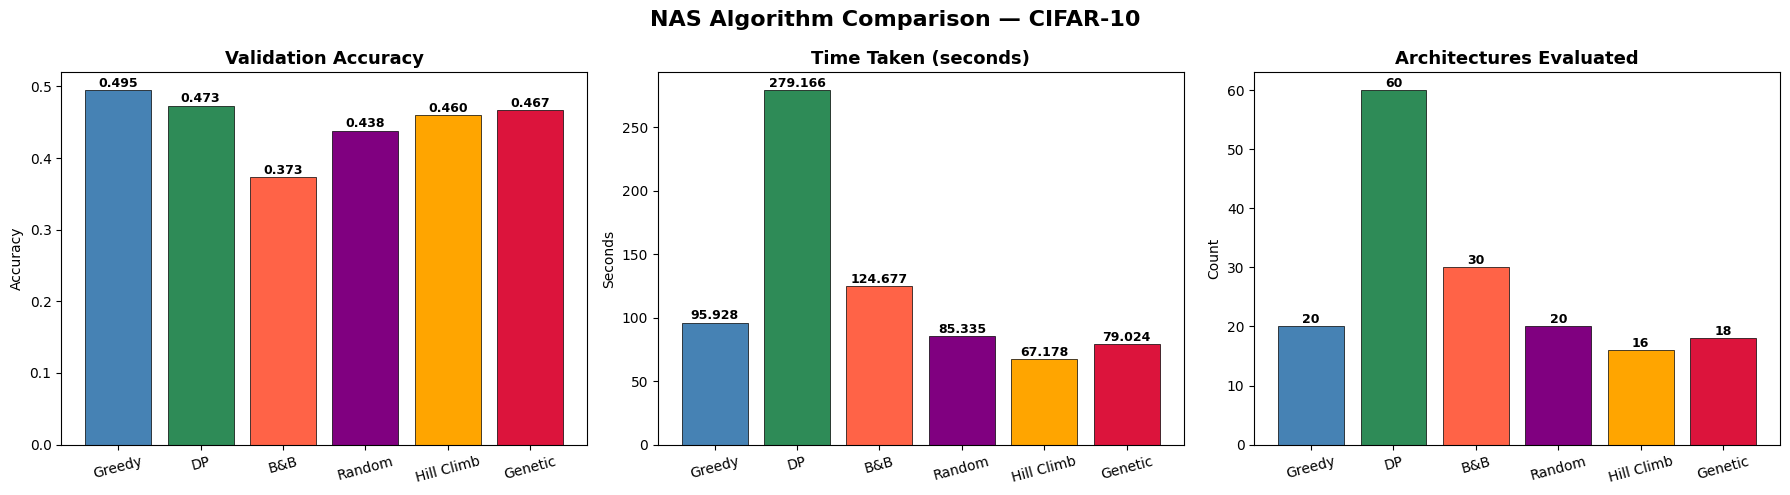


Plot saved as nas_comparison.png


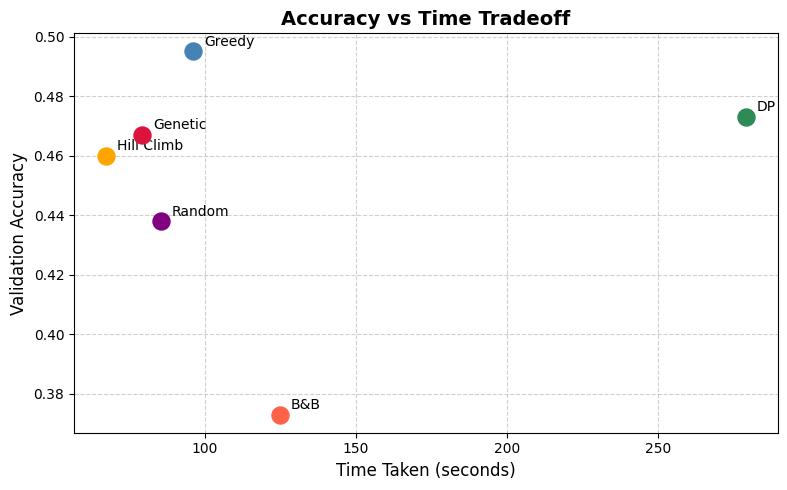

Scatter plot saved as accuracy_vs_time.png


In [ ]:
# Cell 12: Results + Plots
import matplotlib.pyplot as plt

algorithms = ['Greedy', 'DP', 'B&B', 'Random', 'Hill Climb', 'Genetic']
accuracies = [g_acc,   dp_acc, bb_acc, rs_acc,  hc_acc,      ga_acc]
times      = [g_time,  dp_time, bb_time, rs_time, hc_time,   ga_time]
evals      = [g_evals, dp_evals, bb_evals, rs_evals, hc_evals, ga_evals]
colors     = ['steelblue','seagreen','tomato','purple','orange','crimson']

# Print results table
print("\n" + "=" * 70)
print(f"{'FINAL RESULTS COMPARISON':^70}")
print("=" * 70)
print(f"{'Algorithm':<15} {'Accuracy':>10} {'Time (s)':>10} {'Evals':>10}")
print("-" * 70)
for i in range(len(algorithms)):
    print(f"{algorithms[i]:<15} {accuracies[i]:>10.4f} {times[i]:>10.2f} {evals[i]:>10}")
print("=" * 70)

# Find best algorithm
best_idx  = accuracies.index(max(accuracies))
print(f"\nBest Algorithm  : {algorithms[best_idx]}")
print(f"Best Accuracy   : {accuracies[best_idx]:.4f}")

# Plot 1: All 3 charts side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('NAS Algorithm Comparison — CIFAR-10', fontsize=16, fontweight='bold')

for ax, values, title, ylabel in zip(
    axes,
    [accuracies, times, evals],
    ['Validation Accuracy', 'Time Taken (seconds)', 'Architectures Evaluated'],
    ['Accuracy', 'Seconds', 'Count']
):
    bars = ax.bar(algorithms, values, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(values)*0.01,
                f"{val:.3f}" if isinstance(val, float) else str(val),
                ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('nas_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved as nas_comparison.png")

# Plot 2: Accuracy vs Time scatter plot
fig2, ax2 = plt.subplots(figsize=(8, 5))
for i, algo in enumerate(algorithms):
    ax2.scatter(times[i], accuracies[i], color=colors[i], s=150, zorder=5)
    ax2.annotate(algo, (times[i], accuracies[i]),
                 textcoords="offset points", xytext=(8, 4), fontsize=10)
ax2.set_xlabel('Time Taken (seconds)', fontsize=12)
ax2.set_ylabel('Validation Accuracy', fontsize=12)
ax2.set_title('Accuracy vs Time Tradeoff', fontsize=14, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('accuracy_vs_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("Scatter plot saved as accuracy_vs_time.png")

In [ ]:
# Cell 13: Train Best Model
# Pick best architecture across all 6 algorithms
all_results = [
    (g_acc,  g_arch,  'Greedy'),
    (dp_acc, dp_arch, 'DP'),
    (bb_acc, bb_arch, 'Branch & Bound'),
    (rs_acc, rs_arch, 'Random Search'),
    (hc_acc, hc_arch, 'Hill Climbing'),
    (ga_acc, ga_arch, 'Genetic Algorithm')
]

best_result              = max(all_results, key=lambda x: x[0])
best_acc_overall         = best_result[0]
best_arch_overall        = best_result[1]
best_algo                = best_result[2]

print(f"Best Algorithm   : {best_algo}")
print(f"Best Architecture: {best_arch_overall}")
print(f"Best Accuracy    : {best_acc_overall:.4f}")

# Retrain with more epochs for demo
print("\nRetraining best model for 10 epochs...")
best_model = build_model(best_arch_overall).to(device)
optimizer  = optim.Adam(best_model.parameters(), lr=1e-3)
criterion  = nn.CrossEntropyLoss()

best_model.train()
for epoch in range(10):
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(best_model(images), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"  Epoch {epoch+1}/10 | Loss: {total_loss/len(train_loader):.4f}")

torch.save(best_model.state_dict(), 'best_nas_model.pth')
print("\nBest model saved as best_nas_model.pth!")

Best Algorithm   : Greedy
Best Architecture: ['conv3x3', 'maxpool', 'maxpool', 'conv5x5', 'conv5x5']
Best Accuracy    : 0.4950

Retraining best model for 10 epochs...
  Epoch 1/10 | Loss: 1.7713
  Epoch 2/10 | Loss: 1.4934
  Epoch 3/10 | Loss: 1.3745
  Epoch 4/10 | Loss: 1.2579
  Epoch 5/10 | Loss: 1.1884
  Epoch 6/10 | Loss: 1.1331
  Epoch 7/10 | Loss: 1.0671
  Epoch 8/10 | Loss: 1.0011
  Epoch 9/10 | Loss: 0.9504
  Epoch 10/10 | Loss: 0.9109

Best model saved as best_nas_model.pth!
